<a href="https://colab.research.google.com/github/MarianaCastrillonM004/Integracion-de-prospectiva-y-datos/blob/main/Reto_Riesgo_Operacional_FallasTecnologicas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto: Evaluación del Riesgo Operacional en Canales Electrónicos


Como analistas de riesgos de una entidad financiera líder, han recibido la base de datos histórica de Eventos de Riesgo Tecnológico ocurridos en los canales electrónicos (App móvil, Sucursal Virtual, Cajeros).

**Objetivo:** Transformar la base de datos histórica de eventos de riesgo tecnológico en una herramienta de decisión gerencial que permita cuantificar la exposición económica y la eficacia de los controles actuales.



**Variables:**

* Fecha: día en que ocurrió la falla tecnológica.
* Transacciones_Diarias: volumen total de transacciones procesadas ese día en los canales digitales.
* Valor_Transado_MM: valor total transado en millones de USD ese día.
* Frecuencia: número de transacciones fallidas en ese evento.
* Severidad: pérdida económica en MM USD asociada a esa falla.
* Descripcion_Evento: texto que describe el tipo de falla ocurrida.

## 0. Carga de Librerías

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
def clusterizacion(Xi):
    XC = np.random.choice(Xi, size=5)
    XC = np.sort(XC)  # Semillas
    nc = np.zeros((len(Xi), 1)) #Columna vacia para rellenar con clusters

    for k in range(len(Xi)):
        d = np.abs(XC - Xi[k])  # Distancia de un dato a cada semilla
        nc[k] = np.argmin(d)
        nc2 = np.int32(nc[k])
        XC[nc2] = (XC[nc2] + Xi[k]) / 2  # Actualizar centroide

    return XC, nc

## 1. Carga y Exploración de Datos

In [44]:
nxl = '/content/drive/MyDrive/UNIVERSIDAD/Enfasis/Archivos I&P/5. Riesgo Operacional FallasTecnológicas.xlsx'
np.random.seed(42)

# Hoja principal de eventos
XDB = pd.read_excel(nxl, sheet_name='Fallas Tecnológicas')

# Hoja de catálogo de riesgos (niveles)
XRiesgos = pd.read_excel(nxl, sheet_name='Riesgos') #, index_col=0

# Hoja de gestión
XGestion = pd.read_excel(nxl, sheet_name='Gestión')

# Renombrar columnas de forma estandarizada
XDB.columns = ['Fecha', 'Transacciones_Diarias', 'Valor_Transado_MM',
                'Frecuencia', 'Severidad', 'Descripcion_Evento']
XDB.head()

,Fecha,Transacciones_Diarias,Valor_Transado_MM,Frecuencia,Severidad,Descripcion_Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [45]:
# Obtenemos la variable de frecuencia
Xf = np.array(XDB['Frecuencia'])
XCf, ncf = clusterizacion(Xf)

# Obtenemos la variable de Severidad
# Usamos valor absoluto para evitar negativos (errores de datos)
Xs = np.abs(np.array(XDB['Severidad']))
XCs, ncs = clusterizacion(Xs)

# PÉRDIDAS AGREGADAS (LDA): Frecuencia × Severidad
LDA = Xf*Xs
XClda, nclda = clusterizacion(LDA)

# Creamos un dataframe para descargar
df = pd.DataFrame(np.column_stack((Xf,ncf,Xs,ncs,LDA,nclda,XDB.iloc[:,5])))
df.columns = ['Freq', 'Nivel_f','Sev.','Nivel_S','LDA','Nivel_LDA','Riesgos']
df.head()

,Freq,Nivel_f,Sev.,Nivel_S,LDA,Nivel_LDA,Riesgos
0,1,0.0,0.5374,0.0,0.5374,0.0,"Errores visuales menores, problemas de usabili..."
1,4,0.0,1.1978,2.0,4.7912,2.0,"Errores en la interfaz de usuario, fallas en f..."
2,5,1.0,0.4269,0.0,2.1345,1.0,"Errores visuales menores, problemas de usabili..."
3,6,1.0,1.0814,1.0,6.4884,3.0,"Errores en la interfaz de usuario, fallas en f..."
4,7,2.0,1.2105,2.0,8.4735,4.0,"Errores en la interfaz de usuario, fallas en f..."


## 2. Clasificación de Eventos (K-Means Simplificado)

Usamos la función de clusterización de clase para clasificar frecuencia (transacciones fallidas) y severidad (valor pérdida) en 5 niveles.

In [46]:
# Proceso de clústerización
XC=np.random.choice(Xf, size = 5)
XC = np.sort(XC) # Semillas de la cústerización
nc=np.zeros((len(Xf)))

for k in range (len(Xf)): # El primer dato en primera semilla
  d=np.abs(XC-Xf[0]) # Distancia de un dato a cada semilla
  nc[0]=np.argmin(d)
  nc2=np.int32(nc[0])
  XC[nc2,]=(XC[nc2,]+Xf[0])/2

df.iloc[1]


,1
Freq,4
Nivel_f,0.0
Sev.,1.1978
Nivel_S,2.0
LDA,4.7912
Nivel_LDA,2.0
Riesgos,"Errores en la interfaz de usuario, fallas en f..."


## 3. Arquitectura de Matrices
### 3.1 Matriz de Frecuencia

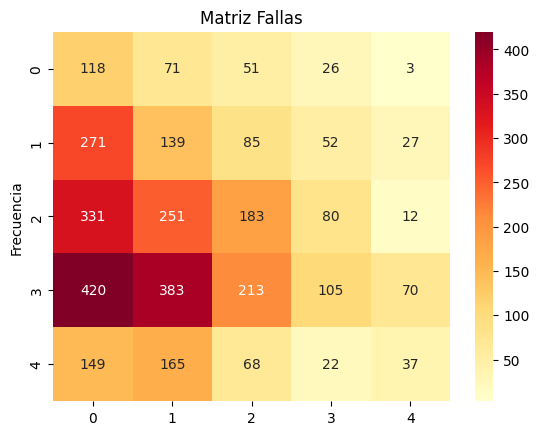

In [47]:
MEf = np.zeros((5, 5))
MEs = np.zeros((5, 5))

for k in range(len(Xf)):
    nf = np.int32(df.iloc[k, 1])  # Fila de frecuencia
    nc = np.int32(df.iloc[k, 3])   # Columna de severidad
    MEf[nf,nc] = MEf[nf,nc]+Xf[k]
    MEs[nf,nc] = (MEs[nf,nc]+Xs[k,])/2 # Costo promedio # Severidad promedio

plt.figure()
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='YlOrRd')
plt.ylabel('Frecuencia')
plt.title('Matriz Fallas')
plt.show()

### 3.2 Matriz de Severidad

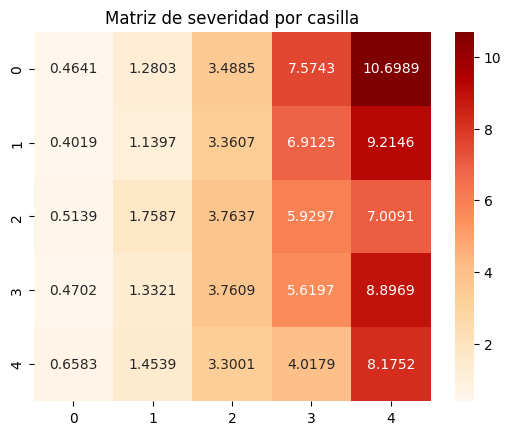

In [48]:
plt.figure()
sns.heatmap(MEs, annot=True, fmt='.4f', cmap='OrRd')
plt.title('Matriz de severidad por casilla')
plt.show()

#El método aplana las diferencias entre frecuencias altas y bajas porque
#trata cada evento igual independientemente de cuántos hay en esa celda.

### 3.3 Matriz de Pérdidas Agregadas (LDA = Frecuencia × Severidad)

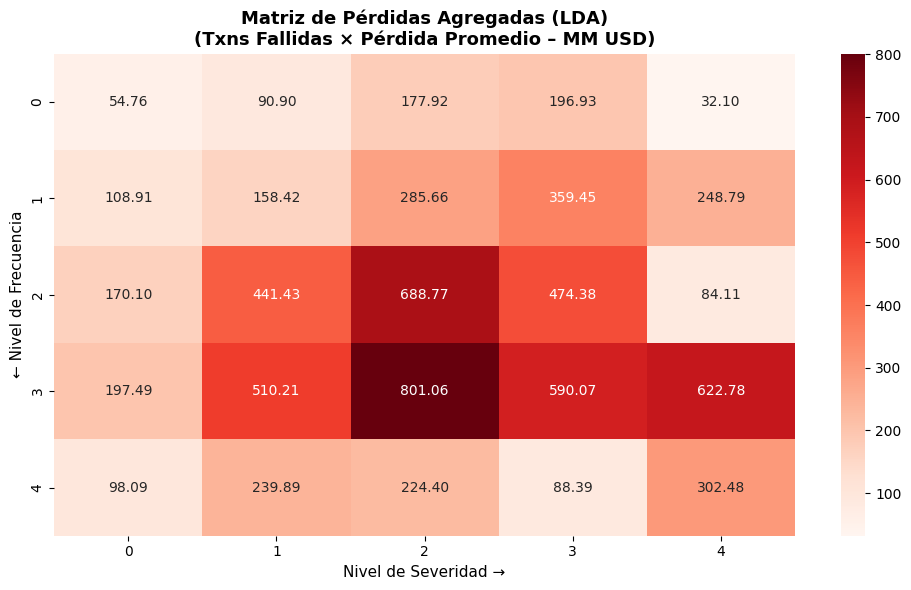

Pérdida Agregada Total: 7247.4869 MM USD


In [49]:
# Pérdida agregada por celda = frecuencia × severidad promedio
MLDA = MEf * MEs

plt.figure(figsize=(10, 6))
sns.heatmap(MLDA, annot=True, fmt='.2f', cmap='Reds')
plt.xlabel('Nivel de Severidad →', fontsize=11)
plt.ylabel('← Nivel de Frecuencia', fontsize=11)
plt.title('Matriz de Pérdidas Agregadas (LDA)\n(Txns Fallidas × Pérdida Promedio – MM USD)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Pérdida Agregada Total: {MLDA.sum():.4f} MM USD")

## 4. Matrices de Impacto y Gestión
### 4.1 Matriz de Impacto

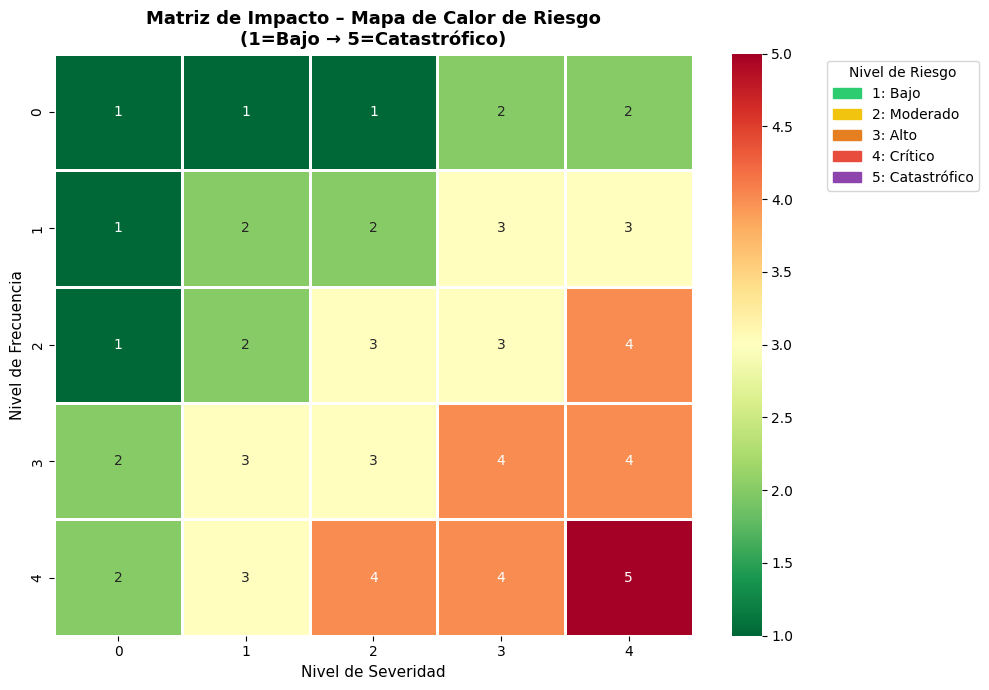

In [50]:
# Matriz de impacto estándar (igual que en clase)
MI= np.array([[1,1,1,2,2],
             [1,2,2,3,3],
             [1,2,3,3,4],
             [2,3,3,4,4],
             [2,3,4,4,5]])

#------------------------------------------------------------------#
# Personalización del Gráfico
#------------------------------------------------------------------#

# Colores semáforo por nivel
colores_impacto = {
    1: '#2ecc71',  # Verde
    2: '#f1c40f',  # Amarillo
    3: '#e67e22',  # Naranja
    4: '#e74c3c',  # Rojo
    5: '#8e44ad'   # Morado
}
niveles_nombre = {1:'Bajo', 2:'Moderado', 3:'Alto', 4:'Crítico', 5:'Catastrófico'}

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(MI, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=1, linecolor='white', ax=ax,
            vmin=1, vmax=5)
plt.xlabel('Nivel de Severidad', fontsize=11)
plt.ylabel('Nivel de Frecuencia', fontsize=11)
plt.title('Matriz de Impacto – Mapa de Calor de Riesgo\n(1=Bajo → 5=Catastrófico)', fontsize=13, fontweight='bold')

# Leyenda de colores
patches = [mpatches.Patch(color=v, label=f'{k}: {niveles_nombre[k]}') for k,v in colores_impacto.items()]
ax.legend(handles=patches, loc='upper left', bbox_to_anchor=(1.2, 1), title='Nivel de Riesgo')

plt.tight_layout()
plt.show()

### 4.2 Matriz de Gestión (Riesgo Residual)

El nivel de gestión representa los controles implementados. Un mayor nivel de gestión reduce las pérdidas catastróficas.

Ingresar el nivel de Gestión (1,2,3,4):2

Nivel de Gestión seleccionado: 2 – Medio


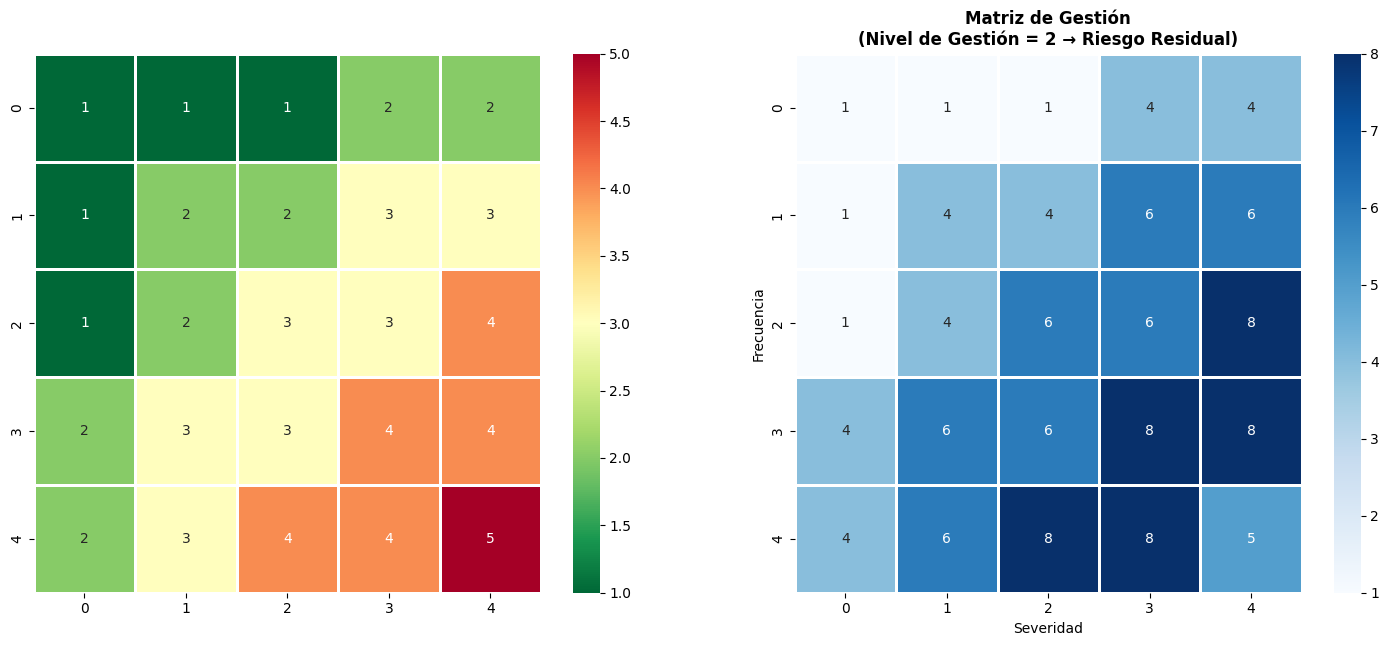

In [51]:
NG=np.int32(input("Ingresar el nivel de Gestión (1,2,3,4):"))

MG = np.copy(MI)
for i in range(5):
    for j in range(5):
        if MG[i, j] > 1 and MG[i, j] < 5:  # Solo zonas intermedias
            MG[i, j] = MG[i, j] * NG

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#------------------------------------------------------------------#
# Personalización del Gráfico
#------------------------------------------------------------------#

sns.heatmap(MI, annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=1, linecolor='white', ax=axes[0], vmin=1, vmax=5)
plt.title(f'Matriz de Impacto\n(Riesgo Inherente – Sin Gestión)', fontsize=12, fontweight='bold')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')

sns.heatmap(MG, annot=True, fmt='d', cmap='Blues',
            linewidths=1, linecolor='white', ax=axes[1])
plt.title(f'Matriz de Gestión\n(Nivel de Gestión = {NG} → Riesgo Residual)', fontsize=12, fontweight='bold')
plt.xlabel('Severidad')
plt.ylabel('Frecuencia')


print(f"\nNivel de Gestión seleccionado: {NG} – {['','Bajo','Medio','Moderado','Alto','Crítico'][NG]}")


In [52]:
#1. Perdida esperada
ps=np.mean(MEs)
print("El promedio simple de severidad por atender una Falla tecnológica es:", ps)

#2. Como no todos las Fallas tecnológicas tienen la misma frecuencia
#Hay pocos fallas que sufren pérdidas extremas
pp=np.round(np.sum(MEf*MEs)/np.sum(MEf),3)
print("El promedio ponderado de severidad por atender una Falla tecnológica es:",pp,"USD")

#3. Se procede a determinar la perdidad ponderada teniendo igualmente la matriz de impacto - Nivel de riego
pnr=np.sum(MEf*MEs*MI)/np.sum(MEf*MI)
print("El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta el nivel de riesgo es:",pnr,"USD")

#4. Se procede a determinar la pérdida ponderada teniendo igualmente la matriz de gestion
png=np.sum(MEf*MEs*MI)/np.sum(MEf*MG)
print(f"El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta un nivel de gestion {NG} es:",png,"USD")

print(f"  Reducción por gestión NG={NG}: {pnr - png:.6f} MM USD")
reduccion_pct = (pnr - png) / pnr * 100
print(f"  Porcentaje de reducción:{reduccion_pct:.1f}%")

El promedio simple de severidad por atender una Falla tecnológica es: 4.047830871818241
El promedio ponderado de severidad por atender una Falla tecnológica es: 2.175 USD
El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta el nivel de riesgo es: 2.8118425171752874 USD
El promedio ponderado de severidad por atender una Falla tecnológica teniendo en cuenta un nivel de gestion 2 es: 1.5079406984639605 USD
  Reducción por gestión NG=2: 1.303902 MM USD
  Porcentaje de reducción:46.4%


### 5. Operational Value at Risk (OpVaR) al 99.9%

El **OpVaR** es el cuantil extremo de la distribución de pérdidas. Al 99.9% indica que solo el 0.1% de los eventos podrían superar ese valor. Se calcula comparando el escenario **No Gestionado (Inherente)** vs **Gestionado (Residual)**.

In [53]:
def caracterizacion(LDA, title=""):

  # Se procede con la creación de la distribución
  plt.figure(figsize=(10,5))
  sns.histplot(LDA, bins=10, kde=True)
  plt.xlabel("Pérdida (MM USD)")
  plt.title(title)
  plt.grid()
  plt.show()

  # Se procede con la caracterización de cada una de las variables
  np.set_printoptions(suppress=True)
  NI = 10
  counts, bin_edges = np.histogram(LDA, bins=NI)
  print("El número de datos por intervalo es:")
  print(counts)
  print("Los intervalos inferiores:")
  print(bin_edges[:-1])
  print("Los intervalos superiores:")
  print(bin_edges[1:])
  XC = (bin_edges[:-1] + bin_edges[1:]) / 2

  # Se configura la tabla de los datos
  Tabla = np.column_stack((bin_edges[:-1], bin_edges[1:], XC, counts))
  dfc = pd.DataFrame(Tabla, columns=['LI','LS','XC','ND'])
  print(dfc)

  # Se procede con la estimación de la media
  fr = counts / np.sum(counts)
  u = np.sum(XC * fr)
  sigma2 = np.sum(fr * (XC - u)**2)
  sigma = np.sqrt(sigma2)
  Cas = np.sum(fr * (XC - u)**3) / sigma**3
  Kur = (np.sum(fr * (XC - u)**4) / sigma**4) - 3

  return u, sigma, Cas, Kur, dfc

RIESGO INHERENTE – LDA No Gestionada


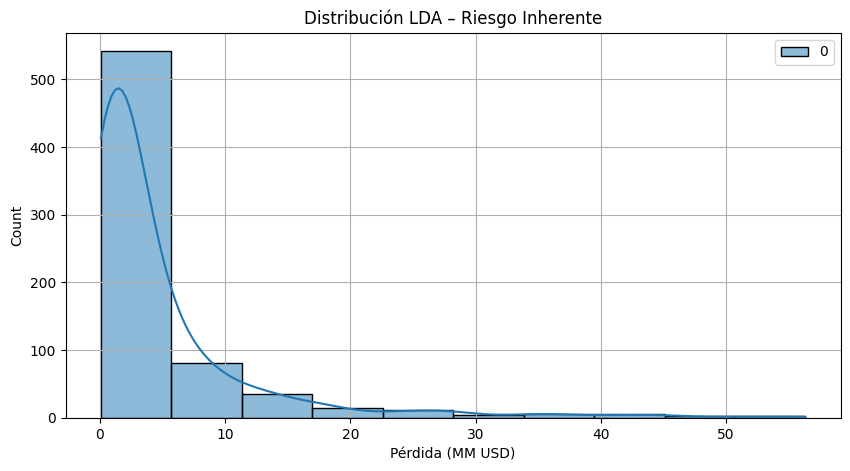

El número de datos por intervalo es:
[542  81  35  14  11   4   5   5   2   2]
Los intervalos inferiores:
[ 0.0842   5.70913 11.33406 16.95899 22.58392 28.20885 33.83378 39.45871
 45.08364 50.70857]
Los intervalos superiores:
[ 5.70913 11.33406 16.95899 22.58392 28.20885 33.83378 39.45871 45.08364
 50.70857 56.3335 ]
         LI        LS         XC     ND
0   0.08420   5.70913   2.896665  542.0
1   5.70913  11.33406   8.521595   81.0
2  11.33406  16.95899  14.146525   35.0
3  16.95899  22.58392  19.771455   14.0
4  22.58392  28.20885  25.396385   11.0
5  28.20885  33.83378  31.021315    4.0
6  33.83378  39.45871  36.646245    5.0
7  39.45871  45.08364  42.271175    5.0
8  45.08364  50.70857  47.896105    2.0
9  50.70857  56.33350  53.521035    2.0
Media    : 5.7533 MM USD
Desv.Std : 7.2271
Asimetría: 3.6085
Curtosis : 14.8788
OpVaR 99.9% Inherente: 54.0942 MM USD
RIESGO RESIDUAL – LDA Gestionada (NG=2)


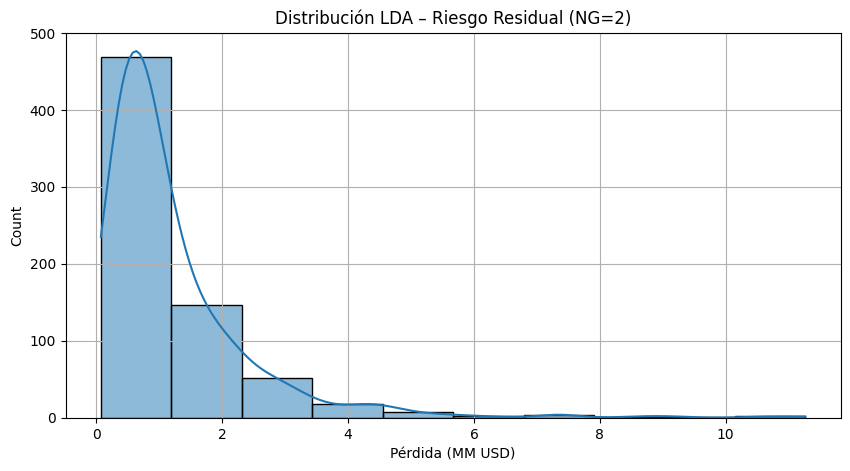

El número de datos por intervalo es:
[469 146  51  18   8   2   3   1   1   2]
Los intervalos inferiores:
[ 0.0704   1.19003  2.30966  3.42929  4.54892  5.66855  6.78818  7.90781
  9.02744 10.14707]
Los intervalos superiores:
[ 1.19003  2.30966  3.42929  4.54892  5.66855  6.78818  7.90781  9.02744
 10.14707 11.2667 ]
         LI        LS         XC     ND
0   0.07040   1.19003   0.630215  469.0
1   1.19003   2.30966   1.749845  146.0
2   2.30966   3.42929   2.869475   51.0
3   3.42929   4.54892   3.989105   18.0
4   4.54892   5.66855   5.108735    8.0
5   5.66855   6.78818   6.228365    2.0
6   6.78818   7.90781   7.347995    3.0
7   7.90781   9.02744   8.467625    1.0
8   9.02744  10.14707   9.587255    1.0
9  10.14707  11.26670  10.706885    2.0
Media    : 1.2611 MM USD
Desv.Std : 1.2332
Asimetría: 3.4163
Curtosis : 16.6973
OpVaR 99.9% Residual: 10.8188 MM USD

Reducción del OpVaR por gestión: 43.2754 MM USD


In [54]:
import numpy as np
# LDA No Gestionada (Riesgo Inherente)
# Using ncf and ncs directly to avoid issues with overwritten 'df'
LDA_inherente = np.array([Xs[k] * MI[np.int32(ncf[k]), np.int32(ncs[k])] for k in range(len(Xf))])

print("RIESGO INHERENTE – LDA No Gestionada")
u_inh, s_inh, cas_inh, kur_inh, tabla_inh = caracterizacion(LDA_inherente, title="Distribución LDA – Riesgo Inherente")
print("Media    :", round(u_inh, 4), "MM USD")
print("Desv.Std :", round(s_inh, 4))
print("Asimetría:", round(cas_inh, 4))
print("Curtosis :", round(kur_inh, 4))
OpVaR_inherente = np.percentile(LDA_inherente, 99.9)
print("OpVaR 99.9% Inherente:", round(OpVaR_inherente, 4), "MM USD")
# LDA Gestionada (Riesgo Residual)
LDA_residual = np.array([Xs[k] * MI[np.int32(df.iloc[k,1]), np.int32(df.iloc[k,3])] / MG[np.int32(df.iloc[k,1]), np.int32(df.iloc[k,3])] for k in range(len(Xf))])

print(f"RIESGO RESIDUAL – LDA Gestionada (NG={NG})")
u_res, s_res, cas_res, kur_res, tabla_res = caracterizacion(LDA_residual, title=f"Distribución LDA – Riesgo Residual (NG={NG})")
print("Media    :", round(u_res, 4), "MM USD")
print("Desv.Std :", round(s_res, 4))
print("Asimetría:", round(cas_res, 4))
print("Curtosis :", round(kur_res, 4))
OpVaR_residual = np.percentile(LDA_residual, 99.9)
print("OpVaR 99.9% Residual:", round(OpVaR_residual, 4), "MM USD")
print()
print("Reducción del OpVaR por gestión:", round(OpVaR_inherente - OpVaR_residual, 4), "MM USD")

## 6. Tablero de Auditoría – Filtro Dinámico

Permite seleccionar cualquier celda de la matriz de pérdidas y ver el listado detallado de eventos que la componen.

In [55]:
import ipywidgets as widgets
from IPython.display import display, HTML
#from ipywidgets import interact, IntSlider

def tablero_auditoria(nivel_frecuencia, nivel_severidad, mostrar_n=20):
    """
    Tablero de Auditoría – Filtro Dinámico por celda de la matriz de Pérdidas Agregadas (MLDA).

    Parámetros:
    -----------
    nivel_frecuencia : int (0-4)
        Representa el nivel de frecuencia (fila de la matriz).
    nivel_severidad  : int (0-4)
        Representa el nivel de severidad (columna de la matriz).
    mostrar_n : int
        Número máximo de eventos detallados a mostrar (por defecto 20).
    """
    nivel_labels_frecuencia = {
        0: 'Muy Baja',
        1: 'Baja',
        2: 'Media',
        3: 'Alta',
        4: 'Muy Alta'
    }
    nivel_labels_severidad = {
        0: 'Muy Baja',
        1: 'Baja',
        2: 'Media',
        3: 'Alta',
        4: 'Muy Alta'
    }

    # Filtrar eventos de la celda seleccionada usando el DataFrame 'df'
    # Convert Nivel_f and Nivel_S to int for accurate comparison
    mascara = (df['Nivel_f'].astype(int) == nivel_frecuencia) & (df['Nivel_S'].astype(int) == nivel_severidad)
    eventos_celda = df[mascara].copy()

    # Get the impact level from the MI matrix
    impacto_nivel = MI[nivel_frecuencia, nivel_severidad]
    impacto_nombre = niveles_nombre[impacto_nivel]

    # Encabezado
    print("\n" + "█" * 70)
    print(f"  🔍 TABLERO DE AUDITORÍA – FILTRO DINÁMICO")
    print(f"  Celda seleccionada (Matriz LDA): Frecuencia [{nivel_frecuencia}] × Severidad [{nivel_severidad}]")
    print(f"  Nivel de Frecuencia: {nivel_labels_frecuencia[nivel_frecuencia]} | Nivel de Severidad: {nivel_labels_severidad[nivel_severidad]}")
    print(f"  Nivel de Impacto (MI): {impacto_nivel} – {impacto_nombre}")
    print("█" * 70)

    if eventos_celda.empty:
        print("  ⚠️  No hay eventos registrados en esta celda para los niveles seleccionados.")
        return

    # Resumen estadístico
    print(f"\n  📊 RESUMEN DE LA CELDA")
    print(f"  {'─'*50}")
    print(f"  Total de eventos:            {len(eventos_celda):>8}")
    print(f"  Frecuencia total (Txns):     {eventos_celda['Freq'].sum():>8.0f}")
    print(f"  Frecuencia promedio (Txns):  {eventos_celda['Freq'].mean():>8.2f}")
    print(f"  Pérdida total (MM USD):      {eventos_celda['Sev.'].sum():>8.4f}")
    print(f"  Pérdida promedio (MM USD):   {eventos_celda['Sev.'].mean():>8.4f}")
    print(f"  Pérdida máxima (MM USD):     {eventos_celda['Sev.'].max():>8.4f}")
    print(f"  LDA total (MM USD):          {eventos_celda['LDA'].sum():>8.4f}")

    # Descripción del tipo de evento predominante
    desc_mode = eventos_celda['Riesgos'].mode()
    if not desc_mode.empty:
        print(f"\n  📋 TIPO DE EVENTO PREDOMINANTE:")
        predominant_desc = desc_mode[0]
        print(f"  {predominant_desc[:120]}..." if len(predominant_desc) > 120 else f"  {predominant_desc}")
    else:
        print("\n  📋 No se pudo determinar un tipo de evento predominante.")

    # Listado detallado de eventos
    print(f"\n  📅 LISTADO DETALLADO DE EVENTOS (mostrando los primeros {min(mostrar_n, len(eventos_celda))} de {len(eventos_celda)} )")
    print(f"  {'─'*100}")

    # Reconstruct the detailed events using XDB's original columns and df's LDA
    eventos_detalle = XDB.loc[eventos_celda.index, ['Fecha', 'Frecuencia', 'Severidad', 'Descripcion_Evento']].copy()
    eventos_detalle['LDA'] = eventos_celda['LDA'] # Add the calculated LDA from df

    # Ensure column names match for display
    eventos_detalle.columns = ['Fecha', 'Txns Fallidas', 'Pérdida (MM)', 'Descripción del Evento', 'LDA (MM)']

    # Format Date
    eventos_detalle['Fecha'] = pd.to_datetime(eventos_detalle['Fecha']).dt.strftime('%Y-%m-%d')

    tabla_mostrar = eventos_detalle.head(mostrar_n).reset_index(drop=True)
    tabla_mostrar.index += 1

    display(HTML(tabla_mostrar.to_html(classes='table table-striped table-hover', escape=False)))
    print(f"  {'─'*100}")

print("✅ Función tablero_auditoria() definida.")
print("\n  Utiliza los sliders a continuación para seleccionar una celda en la matriz de pérdidas:")

# Create interactive sliders for frequency and severity levels
interact(tablero_auditoria,
         nivel_frecuencia=IntSlider(min=0, max=4, step=1, value=2, description='Nivel Frecuencia'),
         nivel_severidad=IntSlider(min=0, max=4, step=1, value=2, description='Nivel Severidad'),
         mostrar_n=widgets.fixed(20)); # Fix mostrar_n to 20 for this interface

✅ Función tablero_auditoria() definida.

  Utiliza los sliders a continuación para seleccionar una celda en la matriz de pérdidas:


interactive(children=(IntSlider(value=2, description='Nivel Frecuencia', max=4), IntSlider(value=2, descriptio…

## 7. Resumen Ejecutivo – Dashboard Gerencial

## Informe Ejecutivo: Evaluación del Riesgo Operacional en Canales Electrónicos


### 1. Arquitectura de Matrices
*   **Matriz de Frecuencia y Severidad:** La clústerización de eventos reveló que la mayoría de las fallas se concentran en niveles de frecuencia **Media-Alta** (2 y 3) y severidad **Baja-Media** (0-2). Esto sugiere problemas recurrentes de usabilidad o errores menores en la interfaz, aunque, se nota que las fallas ocurridas con mucha frecuencia tienen un gran costo en general. La entidad tiene un problema de operación cotidiana, no de catástrofes. Las fallas son frecuentes pero de costo moderado.
*   **Matriz de Pérdidas Agregadas (MLDA):** La suma total de las pérdidas agregadas identificadas asciende a **7247.49 MM USD**. Esta matriz visualiza las zonas de mayor concentración de pérdidas, la cuales se concentran en las de frecuencia nivel 3.

### 2. Matriz de Impacto y Gestión
*   **Matriz de Impacto (MI):** Permite categorizar el riesgo de cada combinación de frecuencia y severidad en una escala de 1 (Bajo) a 5 (Catastrófico). Se observa que los eventos de **impacto crítico o catastrófico** (niveles 4 y 5) son menos frecuentes pero conllevan severidades muy elevadas.
*   **Matriz de Gestión (MG):** Muestra cómo los controles implementados (Nivel de Gestión NG=2 seleccionado en el análisis) modifican el nivel de riesgo inherente, transformándolo en riesgo residual. Cada pérdida se divide por el nivel de gestión de su casilla, reduciendo el impacto económico de cada evento según cuánto control tiene la entidad sobre esa zona de riesgo. Como se observa las que deben ser gestionadas usualmente son las de (4,2) , (3,3), (4,3), (2,4), (3,4).

### 3. Pérdida Esperada (PE)
Se calcularon diferentes perspectivas de la Pérdida Esperada:
*   **Promedio simple de severidad:** `4.0478 MM USD`.
*   **Promedio ponderado por frecuencia:** `2.175 MM USD` (más representativo de las pérdidas).
*   **PE ponderada por nivel de riesgo (inherente):** `2.8118 MM USD` (incorpora el impacto de cada celda). Sin hacer nada, cada evento de falla tecnológica le cuesta en promedio 2.81 MM USD a la entidad considerando su nivel de riesgo. Es el costo de no gestionar.
*   **PE ponderada por nivel de gestión (residual con NG=2):** `1.5079 MM USD`. Esto demuestra una **reducción de `1.3039 MM USD`**, lo que representa un **46.4%** de reducción en la pérdida esperada gracias a la gestión aplicada. Con los controles actuales la entidad logra reducir ese costo casi a la mitad. Eso es bueno, pero todavía significa que cada evento cuesta 1.51 MM USD en promedio, lo cual sigue siendo significativo.

### 4. Operational Value at Risk (OpVaR) al 99.9%
El OpVaR cuantifica la máxima pérdida esperada en un horizonte temporal dado a un cierto nivel de confianza (99.9% en este caso), siendo una medida clave para la reserva de capital.
*   **OpVaR 99.9% Inherente (sin gestión):** `54.0942 MM USD`. En el peor escenario posible (el 0.1% de casos más extremos), la entidad podría perder hasta 54 MM USD en un solo evento sin controles. Ese es el capital que debería reservar si no gestionara nada.
*   **OpVaR 99.9% Residual (con NG=2):** `10.8188 MM USD`. Con los controles actuales ese peor escenario baja a 10.82 MM USD. La reducción de 43.27 MM USD en reserva de capital es dinero que la entidad puede liberar para otros usos porque los controles absorben ese riesgo.

### 5. LDA
con gestión NG=2 la gran mayoría de eventos que antes costaban hasta 5.7 MM USD ahora cuestan menos de 1.19 MM USD. Los controles comprimen las pérdidas hacia la izquierda de la distribución. La desviación estándar baja de 7.23 a 1.23. Los controles no solo reducen las pérdidas, sino que las hacen más predecibles y estables.
Valores muy altos indican que los eventos extremos ocurren con más frecuencia de lo que una distribución normal predice. Curiosamente la curtosis sube con la gestión, lo que significa que aunque los eventos cotidianos se controlaron bien, los eventos catastróficos siguen siendo una amenaza desproporcionada.

La implementación de los controles correspondientes a un Nivel de Gestión de 2 (Medio) resulta en una **reducción del OpVaR de `43.2754 MM USD`**, lo que subraya la efectividad de los controles en la mitigación del riesgo extremo.

### 6. Conclusiones y Recomendaciones

La entidad financiera no enfrenta un problema de catástrofes esporádicas sino de ineficiencia operativa crónica. Las fallas tecnológicas son frecuentes, de costo moderado, y se concentran en niveles medios de riesgo,
Los resultados muestran que, si bien la mayoría de los eventos son de media severidad, la cola de la distribución de pérdidas (eventos catastróficos) tiene un impacto económico muy significativo. Los controles implementados son efectivos, logrando una reducción considerable tanto en la pérdida esperada como en el OpVaR.


**Recomendación Gerencial:**
*   Considerar la implementación de niveles de gestión más altos (NG=3 o NG=4) para los eventos de mayor impacto, especialmente en las celdas de la matriz de impacto clasificadas como Críticas (Nivel 4) y Catastróficas (Nivel 5), donde la inversión en controles puede generar una reducción aún mayor del OpVaR y, por ende, de la exposición al riesgo extremo.
